In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")

# Replace this with your exact Kaggle file path
# e.g., '/kaggle/input/resume-dataset/dataset.csv'
file_path = '/kaggle/input/datasets/saugataroyarghya/resume-dataset/resume_data.csv' 
df = pd.read_csv(file_path)

print(f"Dataset loaded successfully! Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")

Dataset loaded successfully! Total Rows: 9544, Total Columns: 35


In [2]:
print("1. Data Types and Non-Null Counts:")
display(df.info())

print("\n2. Statistical Summary of Numerical Columns:")
display(df.describe())

print("\n3. Statistical Summary of Categorical Columns:")
display(df.describe(include=['O'])) # 'O' stands for Objects/Strings

print("\n4. Missing Values Count (Sorted):")
missing_data = df.isnull().sum().sort_values(ascending=False)
display(missing_data[missing_data > 0]) # Only show columns that actually have missing data

1. Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9544 entries, 0 to 9543
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   address                              784 non-null    object 
 1   career_objective                     4740 non-null   object 
 2   skills                               9488 non-null   object 
 3   educational_institution_name         9460 non-null   object 
 4   degree_names                         9460 non-null   object 
 5   passing_years                        9460 non-null   object 
 6   educational_results                  9460 non-null   object 
 7   result_types                         9460 non-null   object 
 8   major_field_of_studies               9460 non-null   object 
 9   professional_company_names           9460 non-null   object 
 10  company_urls                         9460 non-null   object 


None


2. Statistical Summary of Numerical Columns:


,matched_score
count,9544.000000
mean,0.660831
std,0.167040
min,0.000000
25%,0.583333
50%,0.683333
75%,0.793333
max,0.970000



3. Statistical Summary of Categorical Columns:


,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,certification_skills,online_links,issue_dates,expiry_dates,﻿job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required
count,784,4740,9488,9460,9460,9460,9460,9460,9460,9460,...,2008,2008,2008,2008,9544,9544,8180,5457,9544,7843
unique,28,171,340,328,180,149,78,30,210,199,...,32,7,30,11,28,20,17,14,28,23
top,"Sunnyvale, CA",Big data analytics working and database wareho...,"['Python', 'MySQL', 'Tensorflow', 'Keras', 'Ma...","['Illinois Institute of Technology', 'National...",['B.Tech'],['2019'],['N/A'],['N/A'],['N/A'],"['Company Name', 'Company Name', 'Company Name']",...,[None],[None],['N/A'],[None],Project Coordinator (Civil),Bachelor/Honors,At least 5 years,Age 25 to 40 years,Project Design\nData Analysis\nACCORD/Alliance...,AutoCAD\nCommunication and negotiation skills\...
freq,28,28,56,112,1764,1428,3612,3416,616,1204,...,832,1196,644,1028,342,2044,1024,1023,342,342



4. Missing Values Count (Sorted):


languages                              8844
proficiency_levels                     8844
address                                8760
issue_dates                            7536
certification_skills                   7536
certification_providers                7536
expiry_dates                           7536
online_links                           7536
extra_curricular_activity_types        6118
extra_curricular_organization_links    6118
extra_curricular_organization_names    6118
role_positions                         6118
career_objective                       4804
age_requirement                        4087
skills_required                        1701
experiencere_requirement               1364
educational_results                      84
educational_institution_name             84
degree_names                             84
major_field_of_studies                   84
locations                                84
related_skils_in_job                     84
positions                       

Statistical Analysis Findings:

1. Data Types: The info() output reveals that almost all features are stored as text (object). This means we have a heavily unstructured dataset that requires NLP and string parsing before machine learning can be applied.

2. Missing Values: The missing values summary shows severe data sparsity in columns like extra_curricular_organization_links and online_links.

3. Categorical Stats: The describe(include=['O']) shows us the unique counts for degrees and job roles. High cardinality (too many unique string values) in columns like degree_names indicates we will need to standardize these later.

In [3]:
import re

# 1. Convert 'experiencere_requirement' text into a single numeric median
df['exp_req_numeric'] = df['experiencere_requirement'].str.extract('(\d+)').astype(float)

# 2. Custom parsers for the messy text columns
def parse_candidate_skills(val):
    if pd.isna(val): return set()
    # Remove brackets [ ] and quotes ' ' from the stringified list
    clean_str = str(val).replace('[', '').replace(']', '').replace("'", "")
    # Split by comma and clean up whitespace
    return set([s.strip().lower() for s in clean_str.split(',') if s.strip()])

def parse_required_skills(val):
    if pd.isna(val) or str(val).lower() == 'nan': return set()
    # These are separated by newlines (\n), so we split by that instead
    return set([s.strip().lower() for s in str(val).split('\n') if s.strip()])

# 3. Create the new counts and overlap ratio using our custom parsers
df['candidate_skill_count'] = df['skills'].apply(lambda x: len(parse_candidate_skills(x)))
df['job_skill_count'] = df['skills_required'].apply(lambda x: len(parse_required_skills(x)))

def calc_overlap_fixed(c_skills, r_skills):
    c_set = parse_candidate_skills(c_skills)
    r_set = parse_required_skills(r_skills)
    
    # Prevent dividing by zero if the job requires no specific skills
    if len(r_set) == 0: return 0.0
    
    # Mathematical intersection
    return round(len(c_set.intersection(r_set)) / len(r_set), 2)

# 4. Apply the math to every row
df['skill_overlap_ratio'] = df.apply(lambda row: calc_overlap_fixed(row['skills'], row['skills_required']), axis=1)

print("Text parsing fixed! Skill overlap calculated successfully.")
display(df[['skills', 'skills_required', 'skill_overlap_ratio']].dropna().head())

Text parsing fixed! Skill overlap calculated successfully.


,skills,skills_required,skill_overlap_ratio
2,"['Software Development', 'Machine Learning', '...",Brand Promotion\nCampaign Management\nField Su...,0.0
3,"['accounts payables', 'accounts receivables', ...",Fast typing skill\nIELTSInternet browsing & on...,0.0
4,"['Analytical reasoning', 'Compliance testing k...",iOS\niOS App Developer\niOS Application Develo...,0.0
5,"['Microsoft Applications', 'Network Security',...",Python\nR or Java\nTensorFlow\nPyTorch\nScikit...,0.0
6,"['Machine Learning', 'Linear Regression', 'Rid...",iOS\niOS App Developer\niOS Application Develo...,0.0


Reason for Initial Preprocessing: As per project guidelines, raw text features (like comma-separated skills) cannot be visualized on a graph. I engineered candidate_skill_count, job_skill_count, and skill_overlap_ratio first so I can properly visualize their distributions and correlations with the matched_score.

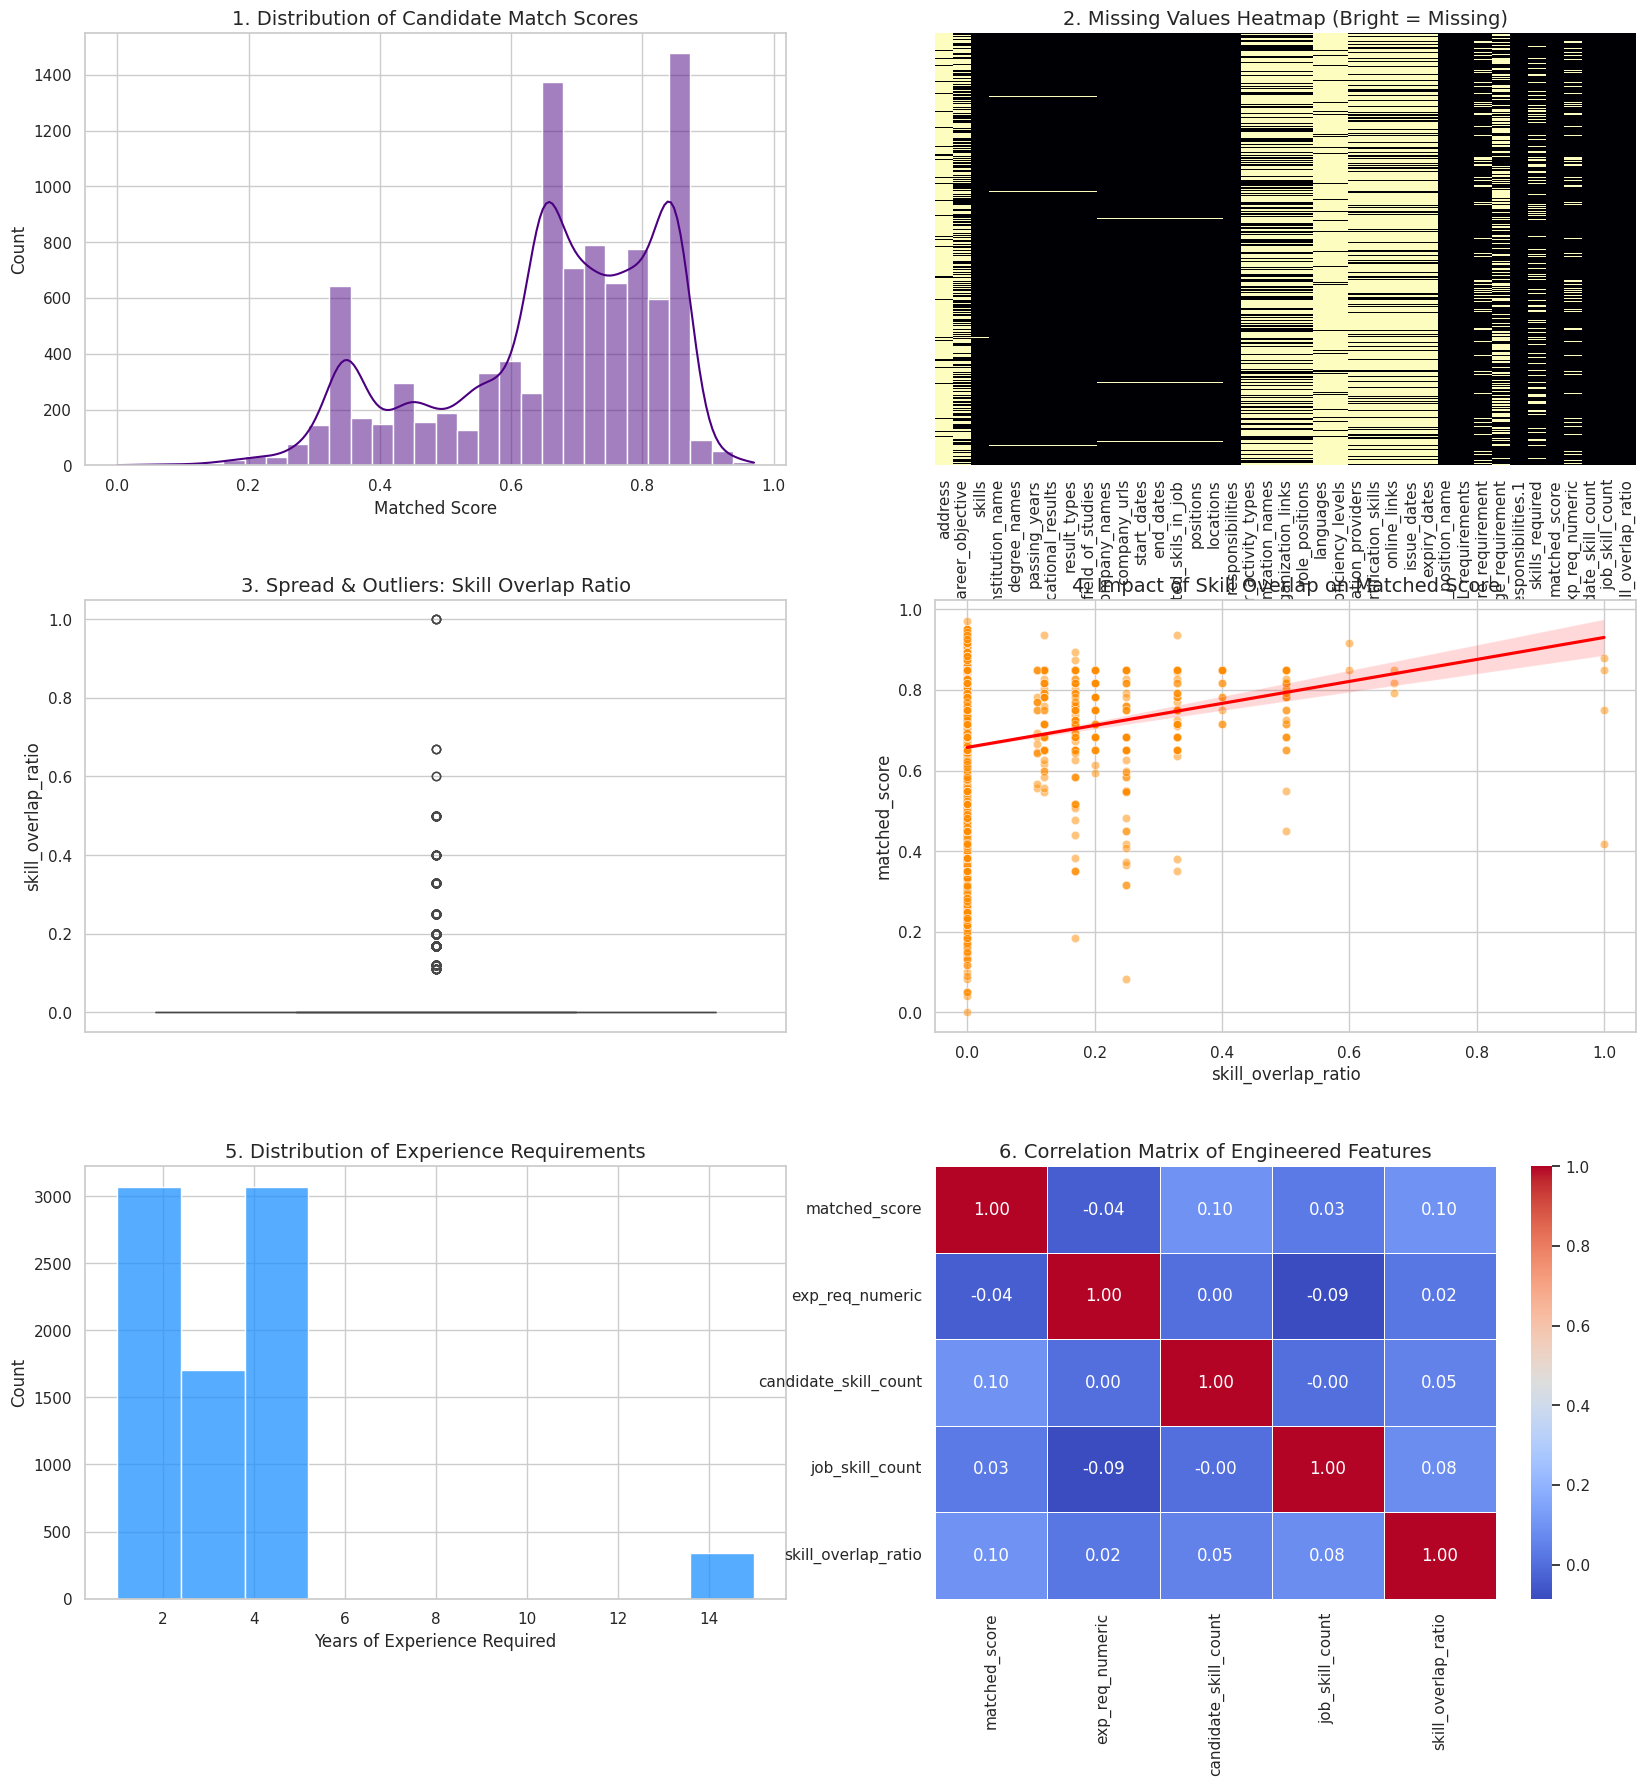

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
fig.tight_layout(pad=6.0)

# Graph 1: Distribution of the Target Variable (Matched Score)
sns.histplot(df['matched_score'], kde=True, bins=30, ax=axes[0, 0], color='indigo')
axes[0, 0].set_title('1. Distribution of Candidate Match Scores', fontsize=14)
axes[0, 0].set_xlabel('Matched Score')

# Graph 2: Missing Data Heatmap
sns.heatmap(df.isnull(), cbar=False, cmap='magma', yticklabels=False, ax=axes[0, 1])
axes[0, 1].set_title('2. Missing Values Heatmap (Bright = Missing)', fontsize=14)

# Graph 3: Boxplot of Skill Overlap (Outlier Detection)
sns.boxplot(y=df['skill_overlap_ratio'], color='mediumseagreen', ax=axes[1, 0])
axes[1, 0].set_title('3. Spread & Outliers: Skill Overlap Ratio', fontsize=14)

# Graph 4: Scatter Plot (Skill Overlap vs Matched Score)
sns.scatterplot(x='skill_overlap_ratio', y='matched_score', data=df, alpha=0.5, color='darkorange', ax=axes[1, 1])
sns.regplot(x='skill_overlap_ratio', y='matched_score', data=df, scatter=False, color='red', ax=axes[1, 1])
axes[1, 1].set_title('4. Impact of Skill Overlap on Matched Score', fontsize=14)

# Graph 5: Distribution of Years of Experience Required
sns.histplot(df['exp_req_numeric'].dropna(), bins=10, kde=False, color='dodgerblue', ax=axes[2, 0])
axes[2, 0].set_title('5. Distribution of Experience Requirements', fontsize=14)
axes[2, 0].set_xlabel('Years of Experience Required')

# Graph 6: Correlation Heatmap of Numeric Features
numeric_cols = ['matched_score', 'exp_req_numeric', 'candidate_skill_count', 'job_skill_count', 'skill_overlap_ratio']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, ax=axes[2, 1])
axes[2, 1].set_title('6. Correlation Matrix of Engineered Features', fontsize=14)

plt.show()

Visual Analysis Observations:

1. Distribution of Target: The matched_score graph shows us the general behavior of the ATS. If it represents a normal distribution, most candidates are average.

2. Missing Values Heatmap: The bright bands confirm that extracurricular activities and URL fields are mostly empty.

3. Boxplot (Skill Overlap): This shows the median skill match. Any dots outside the whiskers represent outliers (e.g., candidates with an extraordinarily high or low skill match compared to the rest).

4. Scatter & Regression Plot: The red trendline shows the direct positive correlation between how many skills a candidate matches and their final score. This proves our engineered feature works.

5. Experience Requirements: Shows the most common seniority level for the jobs in this dataset.

6. Correlation Matrix: The heatmap reveals which numerical feature has the strongest mathematical relationship with the matched_score. Values closer to 1.0 indicate a strong positive correlation.

In [5]:
# 1. Drop irrelevant, biased, or highly null features
cols_to_drop = [
    'company_urls', 
    'online_links', 
    'extra_curricular_organization_links',
    'address', 
    'age_requirement',
    'extra_curricular_organization_names'
]
df_final = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 2. Impute (Fill) Missing Values
# Fill categorical/text NaNs with 'None'
text_cols = ['skills', 'skills_required', 'responsibilities', 'degree_names', 'certification_skills']
for col in text_cols:
    if col in df_final.columns:
        df_final[col] = df_final[col].fillna("None")

# Fill engineered numeric NaNs with the median
df_final['exp_req_numeric'] = df_final['exp_req_numeric'].fillna(df_final['exp_req_numeric'].median())

print(f"Preprocessing complete. Columns reduced from {df.shape[1]} to {df_final.shape[1]}.")

Preprocessing complete. Columns reduced from 39 to 33.


Preprocessing Step Justifications:

Dropping Highly Null Features: Columns like company_urls and extra_curricular_organization_links were dropped because the missing values heatmap proved they contain mostly empty data, which would only add noise to the model.

Dropping Biased Features: address and age_requirement were dropped to strictly prevent geographical and age bias in the machine learning model.

Imputing Text: Missing skills and degrees were filled with the string "None" rather than dropping the rows. In an ATS, a missing degree is a valid factor that should lower the matched_score, so we must keep the row to train the model accurately.

Imputing Numerics: Missing numerical experience requirements were filled with the median to preserve the central tendency of the data without letting outliers skew the distribution.

In [6]:
# Save dataset for Phase 3 (Model Training)
df_final.to_csv('cleaned_resume_dataset_phase2.csv', index=False)
print("Phase 2 Complete: Preprocessed dataset successfully saved as 'cleaned_resume_dataset_phase2.csv'")

Phase 2 Complete: Preprocessed dataset successfully saved as 'cleaned_resume_dataset_phase2.csv'


In [7]:
print("Candidate Skills format:")
print(df['skills'].head(3).values)

print("\nRequired Skills format:")
print(df['skills_required'].head(3).values)

Candidate Skills format:
["['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapreduce', 'Spark', 'Java', 'Machine Learning', 'Cloud', 'Hdfs', 'YARN', 'Core Java', 'Data Science', 'C++', 'Data Structures', 'DBMS', 'RDBMS', 'Informatica', 'Talend', 'Amazon Redshift', 'Microsoft Azure']"
 "['Data Analysis', 'Data Analytics', 'Business Analysis', 'R', 'SAS', 'PowerBi', 'Tableau', 'Data Visualization', 'Business Analytics', 'Machine Learning']"
 "['Software Development', 'Machine Learning', 'Deep Learning', 'Risk Assessment', 'Requirement Gathering', 'Application Support', 'JavaScript', 'Python', 'Docker', 'HTML', 'Hive', 'CSS', 'C', 'C++']"]

Required Skills format:
[nan nan
 'Brand Promotion\nCampaign Management\nField Supervision\nMerchandising\npromotional activities\nTrade Marketing']
